In [109]:
# %%
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [110]:
# %%
csv_files = glob.glob("./1VJusage/df*.csv")

print("找到文件：")
for f in csv_files:
    print(f)

assert len(csv_files) > 0, "当前目录下没有找到 df*.csv 文件"

找到文件：
./1VJusage/df_1VJusage_all.csv


In [111]:
# %%
def extract_title(file_name: str) -> str:
    """
    从 df_x_all.csv 提取 x
    例如：
    df_1VJusage_all.csv -> 1VJusage
    """
    match = re.match(r"df_(.*?)_all\.csv", file_name)
    title = match.group(1)

    # 去掉开头的 0/1、0、1
    title = re.sub(r"^(0/1|0|1)", "", title)
    return title

In [112]:
def smart_format(x):
    if pd.isnull(x):
        return x
    if x == 0:
        return "0"
    # 小于 1e-5 或大于 1e5 用科学计数法
    if abs(x) < 1e-5 or abs(x) >= 1e5:
        return f"{x:.3e}"
    else:
        return f"{x:.5f}"

In [113]:
# %%
def volcano_one_file(file_path, pseudocount=1e-3, figsize=(7, 6)):
    file_name = os.path.basename(file_path)
    title = extract_title(file_name)

    df = pd.read_csv(file_path)
    df = df.copy()
    df.fillna(0, inplace=True)

    # 第一列统一改名为 sample（如果你前面就是 sample，这里不会有影响）
    cols = df.columns.tolist()
    if len(cols) > 0 and cols[0] != "sample":
        cols[0] = "sample"
        df.columns = cols

    # 检查 Category
    if "Category" not in df.columns:
        print(f"{file_name} 跳过：没有 Category 列")
        return None

    # 自动取 Category 后面的所有列作为特征
    category_idx = df.columns.tolist().index("Category")
    feature_cols = df.columns[category_idx + 1 :].tolist()

    if len(feature_cols) == 0:
        print(f"{file_name} 跳过：Category 后没有特征列")
        return None

    # 获取分组
    groups = df["Category"].astype(str).unique().tolist()
    if len(groups) != 2:
        print(
            f"{file_name} 跳过：当前 Category 有 {len(groups)} 组，不是两组。实际分组: {groups}"
        )
        return None

    group1, group2 = groups[0], groups[1]

    # 如果你想固定顺序为 experimental / control，可以用下面这段替换上面两行
    # if set(groups) == {"experimental", "control"}:
    #     group1, group2 = "experimental", "control"
    # else:
    #     group1, group2 = groups[0], groups[1]

    df1 = df[df["Category"].astype(str) == group1]
    df2 = df[df["Category"].astype(str) == group2]

    results = []

    for gene in feature_cols:
        x1 = pd.to_numeric(df1[gene], errors="coerce").fillna(0).values
        x2 = pd.to_numeric(df2[gene], errors="coerce").fillna(0).values
        mean1 = np.mean(x1)
        mean2 = np.mean(x2)

        # FC: group1 / group2
        fc = (mean1 + pseudocount) / (mean2 + pseudocount)
        log2fc = np.log2(fc)

        # Mann-Whitney U test
        try:
            pvalue = mannwhitneyu(x1, x2, alternative="two-sided").pvalue
        except Exception:
            pvalue = np.nan

        results.append([gene, fc, pvalue, log2fc])

    result_df = pd.DataFrame(results, columns=["Gene", "FC", "P-value", "log2FC"])

    # 清理异常值
    cols = ["P-value", "FC", "log2FC"]

    result_df["P-value"] = pd.to_numeric(result_df["P-value"], errors="coerce")
    result_df["FC"] = pd.to_numeric(result_df["FC"], errors="coerce")
    result_df["log2FC"] = pd.to_numeric(result_df["log2FC"], errors="coerce")

    # 设显著阈值
    p_cutoff = 0.05
    fc_cutoff = 0  # 对应 |log2FC| > 1，即 FC > 2 或 < 0.5

    # 绘图
    plot_df = result_df.copy()
    plot_df["neg_log10_p"] = -np.log10(plot_df["P-value"].clip(lower=1e-300))

    plot_df["significant"] = "Not Sig"
    plot_df.loc[
        (plot_df["P-value"] < p_cutoff) & (plot_df["log2FC"] > fc_cutoff),
        "significant",
    ] = "Up"
    plot_df.loc[
        (plot_df["P-value"] < p_cutoff) & (plot_df["log2FC"] < -fc_cutoff),
        "significant",
    ] = "Down"

    out_df = plot_df[plot_df["P-value"] < p_cutoff][
        ["Gene", "log2FC", "P-value", "FC", "significant"]
    ].copy()

    df_pos = out_df[out_df["log2FC"] > 0].sort_values("log2FC", ascending=False)
    df_neg = out_df[out_df["log2FC"] < 0].sort_values("log2FC", ascending=True)

    out_df = pd.concat([df_pos, df_neg], axis=0).reset_index(drop=True)
    export_df = out_df.copy()

    export_df["FC"] = export_df["FC"].apply(smart_format)
    export_df["log2FC"] = export_df["log2FC"].apply(smart_format)
    export_df["P-value"] = export_df["P-value"].apply(smart_format)

    out_csv = file_name.replace(".csv", "_volcano_results.csv")
    export_df.to_csv(out_csv, index=False)

    print(f"{file_name} 结果表已保存：{out_csv}")
    out_csv = file_name.replace(".csv", "_volcano_results.csv")
    export_df.to_csv(out_csv, index=False)
    print(f"{file_name} 结果表已保存：{out_csv}")

    plt.figure(figsize=figsize)

    color_dict = {
        "Up": "#e41a1c",  # 红色
        "Down": "#377eb8",  # 蓝色
        "Not Sig": "#999999",  # 灰色
    }

    for label in ["Not Sig", "Down", "Up"]:
        subdf = plot_df[plot_df["significant"] == label]
        plt.scatter(
            subdf["log2FC"],
            subdf["neg_log10_p"],
            c=color_dict[label],
            label=label,
            alpha=0.85,
            s=50,
            edgecolors="white",
            linewidths=0.8,
        )
    # 阈值线
    plt.axhline(-np.log10(p_cutoff), linestyle="--")
    plt.axvline(fc_cutoff, linestyle="--")
    plt.axvline(-fc_cutoff, linestyle="--")

    plt.xlabel(f"log2(Fold Change)\n({group1} / {group2})")
    plt.ylabel("-log10(P value)")
    plt.title(title)

    plt.legend()
    plt.tight_layout()

    out_png = file_name.replace(".csv", "_volcano.png")
    plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

    print(f"{file_name} 火山图已保存：{out_png}")

    return out_df


df_1VJusage_all.csv 结果表已保存：df_1VJusage_all_volcano_results.csv
df_1VJusage_all.csv 结果表已保存：df_1VJusage_all_volcano_results.csv


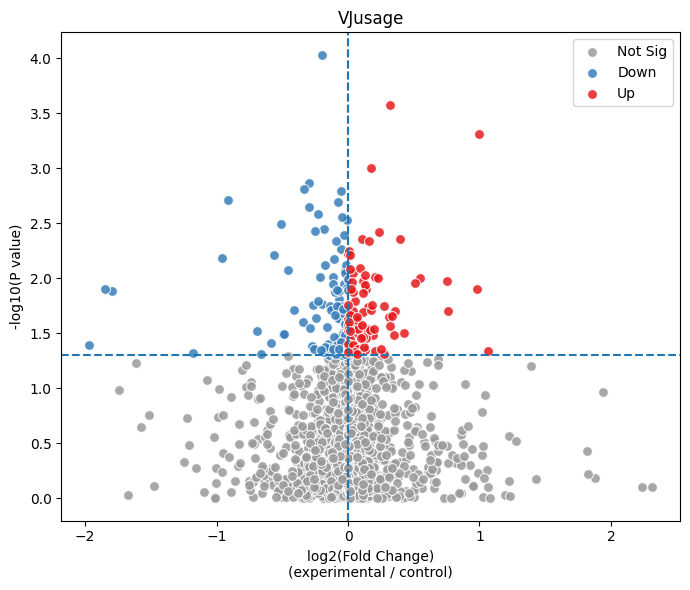

df_1VJusage_all.csv 火山图已保存：df_1VJusage_all_volcano.png


In [114]:
# %%
all_results = {}

for file_path in csv_files:
    print("\n" + "=" * 60)
    res = volcano_one_file(file_path)
    if res is not None:
        all_results[os.path.basename(file_path)] = res

In [115]:
# %%
# 例子：查看第一个文件的前10行结果
if len(all_results) > 0:
    first_key = list(all_results.keys())[0]
    print("当前查看：", first_key)
    display(all_results[first_key].head(10))

当前查看： df_1VJusage_all.csv


,Gene,log2FC,P-value,FC,significant
0,TRAV12-2;TRAJ40,1.061816,0.045865,2.087557,Up
1,TRAV13-1;TRAJ3,0.995570,0.000486,1.993868,Up
2,TRAV29DV5;TRAJ44,0.981496,0.012610,1.974512,Up
3,TRAV17;TRAJ57,0.763447,0.019629,1.697542,Up
4,TRAV5;TRAJ10,0.754630,0.010580,1.687199,Up
5,TRAV8-1;TRAJ48,0.544403,0.010017,1.458416,Up
6,TRBV11-3;TRBJ2-7,0.508477,0.010946,1.422547,Up
7,TRAV2;TRAJ3,0.423244,0.031308,1.340939,Up
8,TRAV8-2;TRAJ5,0.392495,0.004367,1.312661,Up
9,TRAV21;TRAJ7,0.354628,0.020005,1.278655,Up
